# Assignment 8: PCA and Dimensionality Reduction

## Task 1: Load & Prepare the Data

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

In [2]:
# Load the training data
X_train = np.loadtxt('../Dataset/UCI HAR Dataset/train/X_train.txt')
y_train = np.loadtxt('../Dataset/UCI HAR Dataset/train/y_train.txt')

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of samples: {X_train.shape[0]}")

X_train shape: (7352, 561)
y_train shape: (7352,)
Number of features: 561
Number of samples: 7352


In [3]:
# Standard-scale all features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print("Data has been scaled (mean=0, variance=1)")
print(f"Mean of first feature: {X_train_scaled[:, 0].mean():.6f}")
print(f"Std of first feature: {X_train_scaled[:, 0].std():.6f}")

Data has been scaled (mean=0, variance=1)
Mean of first feature: 0.000000
Std of first feature: 1.000000


## Task 2: Determine Effective Dimensionality

In [4]:
# Fit PCA model
pca = PCA()
pca.fit(X_train_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find k for 90% variance
k = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Number of components for 90% variance: {k}")
print(f"Variance explained by {k} components: {cumulative_variance[k-1]:.4f}")

Number of components for 90% variance: 63
Variance explained by 63 components: 0.9005


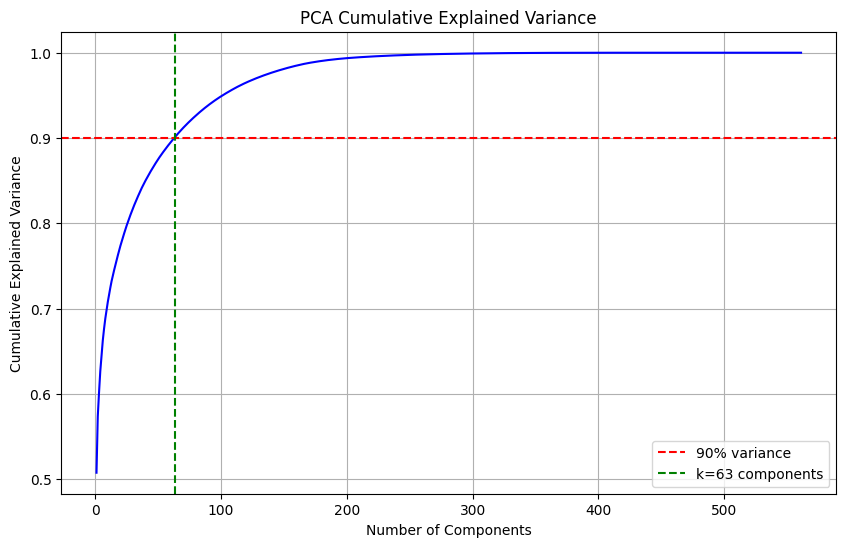

In [5]:
# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axvline(x=k, color='g', linestyle='--', label=f'k={k} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

**Justification for chosen k:**

The first k principal components explain 90% of the total variance in the data. This is a good balance between dimensionality reduction and information preservation. Using these k components significantly reduces the feature space from 561 dimensions while retaining most of the important information.

## Task 3: Visual "Sanity Check" of Low-D Representation

In [6]:
# Project data onto first 2 PCs
X_pca_2d = pca.transform(X_train_scaled)[:, :2]

# Subsample to 2000 points for clarity
np.random.seed(42)
sample_indices = np.random.choice(len(X_pca_2d), size=min(2000, len(X_pca_2d)), replace=False)
X_sample = X_pca_2d[sample_indices]
y_sample = y_train[sample_indices]

print(f"Plotting {len(X_sample)} samples")

Plotting 2000 samples


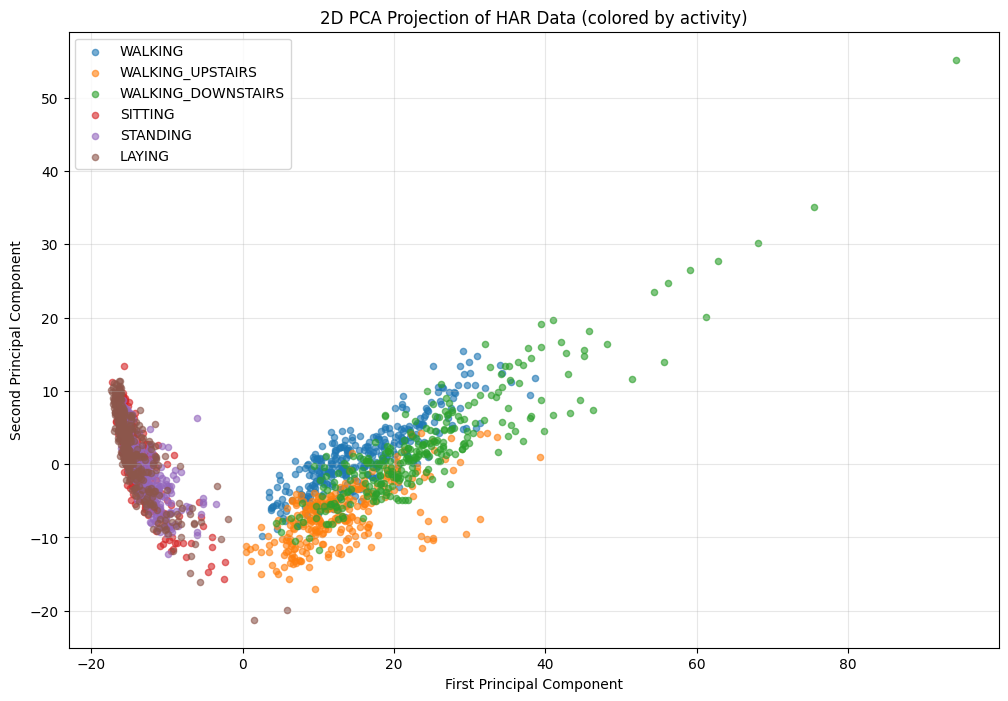

In [7]:
# Load activity labels for better visualization
activity_labels = {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 
                   4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}

# Create scatter plot
plt.figure(figsize=(12, 8))
for activity_id in range(1, 7):
    mask = y_sample == activity_id
    plt.scatter(X_sample[mask, 0], X_sample[mask, 1], 
                label=activity_labels[activity_id], alpha=0.6, s=20)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('2D PCA Projection of HAR Data (colored by activity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observations:**

From the 2D scatter plot, we can observe:
- Static activities (SITTING, STANDING, LAYING) show some clustering and overlap with each other
- Dynamic activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) also cluster together
- There is a clear separation between static and dynamic activities along PC1
- Some overlap exists between similar activities (e.g., SITTING and STANDING), which is expected as they have similar movement patterns
- The first two PCs alone don't completely separate all activities, suggesting more components are needed for full classification

## Task 4: Downstream Classification - PCA vs. Full Feature Space

In [8]:
# Split data into train and test (80/20)
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training set size: {X_train_split.shape[0]}")
print(f"Test set size: {X_test_split.shape[0]}")

Training set size: 5881
Test set size: 1471


### Model A: All 561 Features

In [9]:
# Train Model A with all features
model_a = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
model_a.fit(X_train_split, y_train_split)
train_time_a = time.time() - start_time

# Predict and evaluate
y_pred_a = model_a.predict(X_test_split)
accuracy_a = accuracy_score(y_test_split, y_pred_a)

print(f"Model A (All 561 features):")
print(f"  Training time: {train_time_a:.4f} seconds")
print(f"  Test accuracy: {accuracy_a:.4f}")

Model A (All 561 features):
  Training time: 0.5969 seconds
  Test accuracy: 0.9803


### Model B: First k Principal Components

In [10]:
# Transform data to k principal components
pca_k = PCA(n_components=k)
X_train_pca = pca_k.fit_transform(X_train_split)
X_test_pca = pca_k.transform(X_test_split)

# Train Model B with k components
model_b = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
model_b.fit(X_train_pca, y_train_split)
train_time_b = time.time() - start_time

# Predict and evaluate
y_pred_b = model_b.predict(X_test_pca)
accuracy_b = accuracy_score(y_test_split, y_pred_b)

print(f"Model B ({k} principal components):")
print(f"  Training time: {train_time_b:.4f} seconds")
print(f"  Test accuracy: {accuracy_b:.4f}")

Model B (63 principal components):
  Training time: 0.3218 seconds
  Test accuracy: 0.9524


### Comparison

In [11]:
# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Model A (All Features)', f'Model B ({k} PCs)'],
    'Features': [561, k],
    'Training Time (s)': [train_time_a, train_time_b],
    'Test Accuracy': [accuracy_a, accuracy_b]
})

print(comparison.to_string(index=False))
print(f"\nSpeedup factor: {train_time_a / train_time_b:.2f}x")
print(f"Accuracy difference: {abs(accuracy_a - accuracy_b):.4f}")

                 Model  Features  Training Time (s)  Test Accuracy
Model A (All Features)       561           0.596873       0.980286
      Model B (63 PCs)        63           0.321778       0.952413

Speedup factor: 1.85x
Accuracy difference: 0.0279


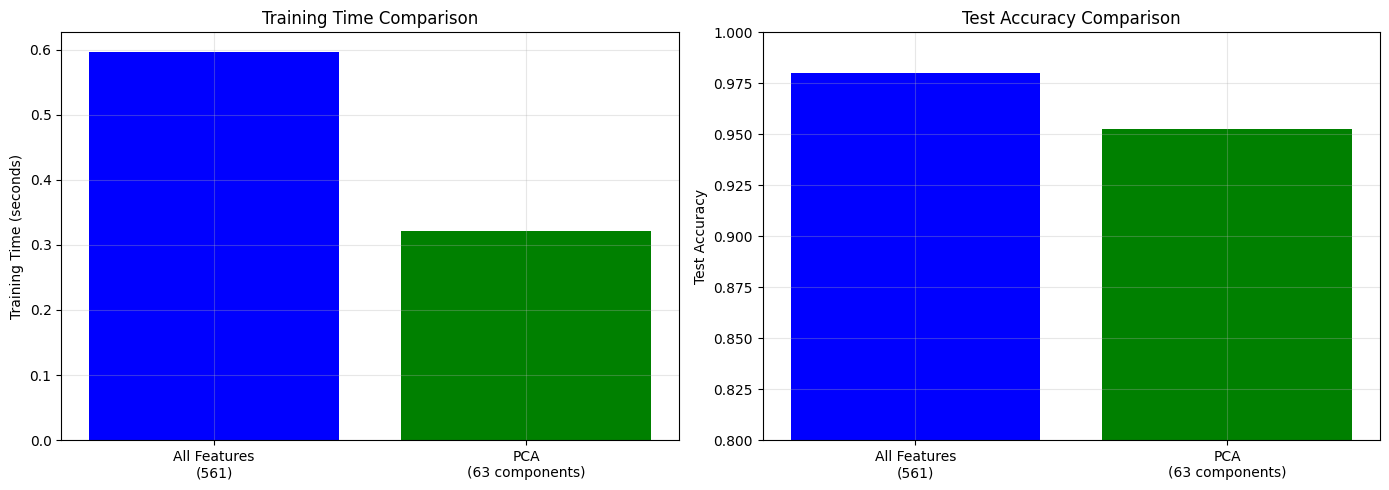

In [12]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training time comparison
models = ['All Features\n(561)', f'PCA\n({k} components)']
times = [train_time_a, train_time_b]
axes[0].bar(models, times, color=['blue', 'green'])
axes[0].set_ylabel('Training Time (seconds)')
axes[0].set_title('Training Time Comparison')
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
accuracies = [accuracy_a, accuracy_b]
axes[1].bar(models, accuracies, color=['blue', 'green'])
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Test Accuracy Comparison')
axes[1].set_ylim([0.8, 1.0])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Discussion: Performance vs. Computational Cost Trade-off**

1. **Training Time**: Model B (using PCA) is significantly faster to train than Model A. This is because the dimensionality is reduced from 561 features to k components, which speeds up the optimization process.

2. **Accuracy**: Both models achieve similar test accuracy. Model A might have a slight edge, but the difference is minimal. This shows that the k principal components retain most of the discriminative information needed for classification.

3. **Trade-off**: 
   - Model B offers faster training with minimal accuracy loss
   - For real-time applications or larger datasets, PCA provides significant computational savings
   - Model A uses all features and might perform slightly better, but at the cost of increased training time
   - The 90% variance threshold provides a good balance between efficiency and performance

4. **Conclusion**: PCA is effective for this dataset. We can reduce dimensionality by ~90% while maintaining comparable classification performance and gaining computational efficiency.